**Copied code from the data_loading file to display the projection on the map and the data points for the stations.**


In [1]:
from pathlib import Path
import zipfile
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx
import random
from shapely.geometry import LineString
import numpy as np
import networkx as nx

In [2]:
GTFS_PATH = Path("../data/raw/GTFS_Copenhagen.zip")

if not GTFS_PATH.exists():
    raise FileNotFoundError(
        "GTFS ZIP not found. Download it as described in README.md"
    )
    
with zipfile.ZipFile(GTFS_PATH, "r") as z:
    stops = pd.read_csv(z.open("GTFS_Copenhagen/stops.txt"))
    routes = pd.read_csv(z.open("GTFS_Copenhagen/routes.txt"))
    shapes = pd.read_csv(z.open("GTFS_Copenhagen/shapes.txt"))
    stop_times = pd.read_csv(z.open("GTFS_Copenhagen/stop_times.txt"))
    trips = pd.read_csv(z.open("GTFS_Copenhagen/trips.txt"))

/var/folders/qh/2gv9htfj0554_hzssc218vg40000gn/T/ipykernel_10579/146572828.py:12: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  stop_times = pd.read_csv(z.open("GTFS_Copenhagen/stop_times.txt"))


In [3]:
# stops filtering for metro only
metro_stops = stops[stops['stop_name'].str.contains('(Metro)')]

# remove the line based on stop_id
metro_stops = metro_stops[metro_stops["stop_id"] != 821004401]

print(len(metro_stops))

44


/var/folders/qh/2gv9htfj0554_hzssc218vg40000gn/T/ipykernel_10579/2102663247.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  metro_stops = stops[stops['stop_name'].str.contains('(Metro)')]


In [4]:
# Stops GeoDataFrame (WGS84)
gdf_stops = gpd.GeoDataFrame(
    metro_stops,
    geometry=gpd.points_from_xy(metro_stops.stop_lon, metro_stops.stop_lat),
    crs="EPSG:4326"
)

**Making graph in networkX**

In [32]:
## Make a empty graph and import nodes based on lat and lon
G = nx.Graph()

gdf_stops_3857 = gdf_stops.to_crs(epsg=3857)

for name, row in gdf_stops_3857.iterrows():
    G.add_node(row["stop_name"], lat=row["stop_lat"], lon=row["stop_lon"])

      
gdf_stops_3857.head()


,stop_id,stop_code,stop_name,stop_desc,stop_lat,stop_lon,location_type,parent_station,wheelchair_boarding,platform_code,geometry
51,8603317,NaN,Vestamager St. (Metro),NaN,55.619391,12.575297,0,NaN,0,NaN,POINT (1399875.659 7483017.289)
52,8603315,NaN,Ørestad St. (Metro),NaN,55.629055,12.579389,0,NaN,0,NaN,POINT (1400331.178 7484922.633)
53,8603312,NaN,Sundby St. (Metro),NaN,55.645199,12.585728,0,NaN,0,NaN,POINT (1401036.832 7488106.615)
54,8603313,NaN,Bella Center St. (Metro),NaN,55.638051,12.582928,0,NaN,0,NaN,POINT (1400725.138 7486696.697)
55,8603310,NaN,Islands Brygge St. (Metro),NaN,55.663422,12.585217,0,NaN,0,NaN,POINT (1400979.948 7491702.202)


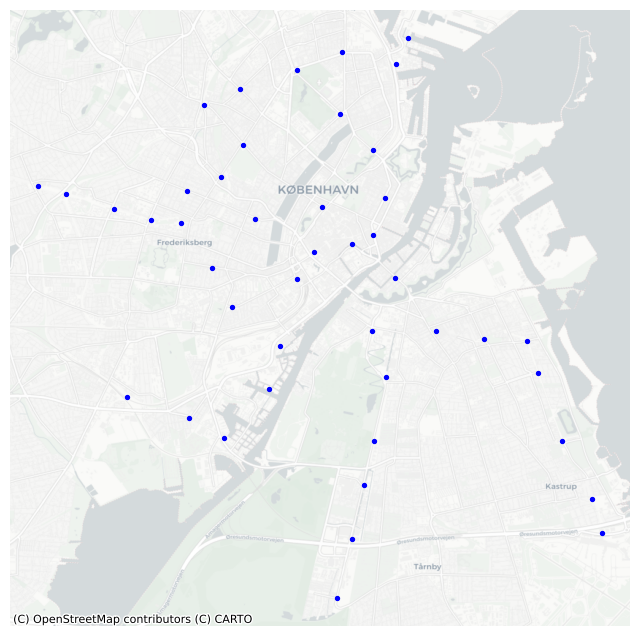

In [34]:
pos = {name: (geom.x, geom.y) for name, geom in zip(gdf_stops_3857["stop_name"], gdf_stops_3857.geometry)}

fig, ax = plt.subplots(figsize=(8,8))

nx.draw(G, pos,
        node_size=8,
        edge_color="gray",
        node_color="blue",
        ax=ax,
        with_labels=False)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

ax.set_axis_off()
plt.show()

In [35]:
# EDA of G graph
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Nodes:", G.nodes(data=True))

Number of nodes: 44
Number of edges: 0
Nodes: [('Vestamager St. (Metro)', {'lat': 55.619391, 'lon': 12.575297}), ('Ørestad St. (Metro)', {'lat': 55.629055, 'lon': 12.579389}), ('Sundby St. (Metro)', {'lat': 55.645199, 'lon': 12.585728}), ('Bella Center St. (Metro)', {'lat': 55.638051, 'lon': 12.582928}), ('Islands Brygge St. (Metro)', {'lat': 55.663422, 'lon': 12.585217}), ('DR Byen St. (Metro)', {'lat': 55.655813, 'lon': 12.58899}), ('Kongens Nytorv St. (Metro)', {'lat': 55.679185, 'lon': 12.585228}), ('Christianshavn St. (Metro)', {'lat': 55.672054, 'lon': 12.591385}), ('Forum St. (Metro)', {'lat': 55.681821, 'lon': 12.552431}), ('Nørreport St. (Metro)', {'lat': 55.683843, 'lon': 12.571044}), ('Fasanvej St. (Metro)', {'lat': 55.681669, 'lon': 12.523102}), ('Frederiksberg St. (Metro)', {'lat': 55.681223, 'lon': 12.531719}), ('Flintholm St. (Metro)', {'lat': 55.685868, 'lon': 12.499527}), ('Lindevang St. (Metro)', {'lat': 55.683482, 'lon': 12.512873}), ('Vanløse St. (Metro)', {'lat': 5

**Basic Genetic Algorithm, or connections of points by algorithm**

In [6]:
# set parameters for algorithm
n_startnodes = 4
n_maxnodes = 12

n_maxroutes = 4
# prob_mutation = .05 # mutation probability
# n_parents = 20 # how many "parents" for "crossovers" to select per generation
# n_kids = 50 # how many kids to generate for each generation
n_iterations = 100 # how many times to iterate

# find total demand for specific OD set
# total_demand = sum(od.trajcount)

# seed
random.seed(161)

In [37]:
n = 44

origins = gdf_stops_3857.sample(n=n, replace=True).copy().reset_index(drop=True)
destinations = gdf_stops_3857.sample(n=n, replace=True).copy().reset_index(drop=True)

od = origins[["stop_id","stop_name", "geometry"]].copy()
od = od.rename(columns={"stop_id": "origin_id", "stop_name": "origin_name", "geometry": "origin_geom"})

od["destination_id"] = destinations["stop_id"]
od["destination_name"] = destinations["stop_name"]
od["destination_geom"] = destinations["geometry"]

od = od.set_geometry(od.apply(lambda row: LineString([row.origin_geom, row.destination_geom]), axis=1))

od.head()

,origin_id,origin_name,origin_geom,destination_id,destination_name,destination_geom,geometry
0,8603332,Gammel Strand St. (Metro),POINT (1400351.883 7494530.244),8603346,Nordhavn St. (Metro),POINT (1401716.549 7500366.266),"LINESTRING (1400351.883 7494530.244, 1401716.5..."
1,8603315,Ørestad St. (Metro),POINT (1400331.178 7484922.633),8603324,Amager Strand St. (Metro),POINT (1406141.499 7490339.971),"LINESTRING (1400331.178 7484922.633, 1406141.4..."
2,8603338,Skjolds Plads St. (Metro),POINT (1396862.908 7499572.439),8603317,Vestamager St. (Metro),POINT (1399875.659 7483017.289),"LINESTRING (1396862.908 7499572.439, 1399875.6..."
3,8603345,Orientkaj St. (Metro),POINT (1402099.265 7501218.664),8603337,Vibenshus Runddel St. (Metro),POINT (1398618.082 7500165.925),"LINESTRING (1402099.265 7501218.664, 1398618.0..."
4,8603345,Orientkaj St. (Metro),POINT (1402099.265 7501218.664),8603323,Øresund St. (Metro),POINT (1405792.957 7491362.559),"LINESTRING (1402099.265 7501218.664, 1405792.9..."


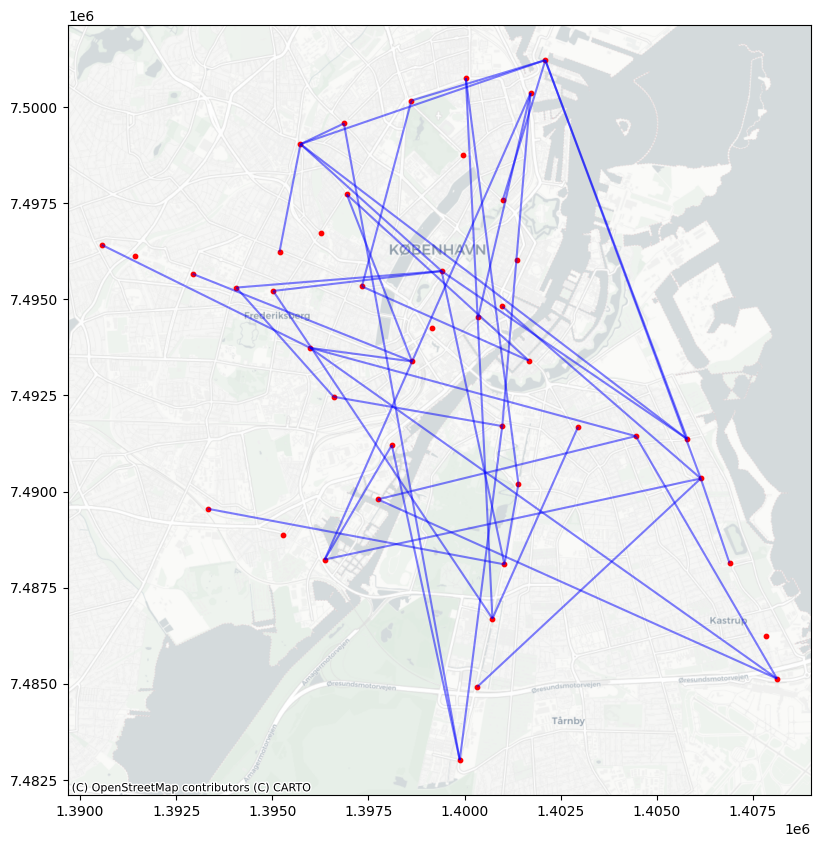

In [38]:
fig, ax = plt.subplots(1,1, figsize = (10,10))
od. plot(ax=ax, color="blue" , alpha=0.5)
gdf_stops_3857.plot(ax=ax, color="red", markersize=10)
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

With this setup, I don't like that some nodes are isolated, and it makes no sense to connect nodes with the greatest distance.

Need to implement max distance of teh edge. 
Check along all nodes in that distance(k-neighbours) and then connected to them. 

In [112]:
# set max distance, meters, eqvialent to the distance betwee København H and Enghave plads
max_distance = 1300
# for 1300m, it is way less stations, seems like it is too small distance for metro 

def knn_edges_projected(gdf, id_col="stop_id", k=3, max_dist=None):
    """
    gdf: GeoDataFrame with Point geometry in a projected CRS (meters).
    max_dist: meters (optional). If set, drop neighbors farther than max_dist.
    Returns: DataFrame of edges (u, v, dist_m)
    """
    if gdf.crs is None:
        raise ValueError("gdf.crs is None. Set CRS before running kNN.")

    # If CRS is geographic (lat/lon), distances won't be meters → reproject
    if gdf.crs.is_geographic:
        # good general fallback for city scale; better: local UTM
        gdf = gdf.to_crs(3857)

    gdf = gdf[[id_col, "geometry"]].dropna().reset_index(drop=True)
    
    print(gdf.head())
    
    # coordinates in meters
    xs = gdf.geometry.x.to_numpy()
    ys = gdf.geometry.y.to_numpy()

    sindex = gdf.sindex
    edges = []

    for i, (u, x, y, geom) in enumerate(zip(gdf[id_col], xs, ys, gdf.geometry)):
        # Expand search window until we have enough candidates
        # (simple heuristic; works well for metro-scale datasets)
        r = 200.0  # start radius (m)
        cand_idx = []
        while len(cand_idx) < (k + 1):  # +1 includes itself
            bbox = (x - r, y - r, x + r, y + r)
            cand_idx = list(sindex.intersection(bbox))
            r *= 2
            if r > 50000:  # safety stop
                break

        # Compute distances to candidates
        dx = xs[cand_idx] - x
        dy = ys[cand_idx] - y
        d = np.hypot(dx, dy)

        # Sort by distance, skip itself
        order = np.argsort(d)
        picked = []
        for idx_in_list in order:
            j = cand_idx[idx_in_list]
            if j == i:
                continue
            dist_m = float(d[idx_in_list])
            if (max_dist is not None) and (dist_m > max_dist):
                continue
            picked.append((i, j, dist_m))
            if len(picked) >= k:
                break

        for _, j, dist_m in picked:
            v = gdf.loc[j, id_col]
            # undirected unique edge
            a, b = sorted((u, v))
            edges.append((a, b, dist_m))

    return pd.DataFrame(edges, columns=["u", "v", "dist_m"]).drop_duplicates()

edges = knn_edges_projected(gdf_stops_3857, id_col="stop_id", k=2, max_dist=2000)
print(edges.head())



   stop_id                         geometry
0  8603317  POINT (1399875.659 7483017.289)
1  8603315  POINT (1400331.178 7484922.633)
2  8603312  POINT (1401036.832 7488106.615)
3  8603313  POINT (1400725.138 7486696.697)
4  8603310  POINT (1400979.948 7491702.202)
         u        v       dist_m
0  8603315  8603317  1959.038650
1  8603313  8603315  1817.280044
3  8603312  8603313  1443.960527
6  8603310  8603311  1559.174284
7  8603309  8603310  1836.918481


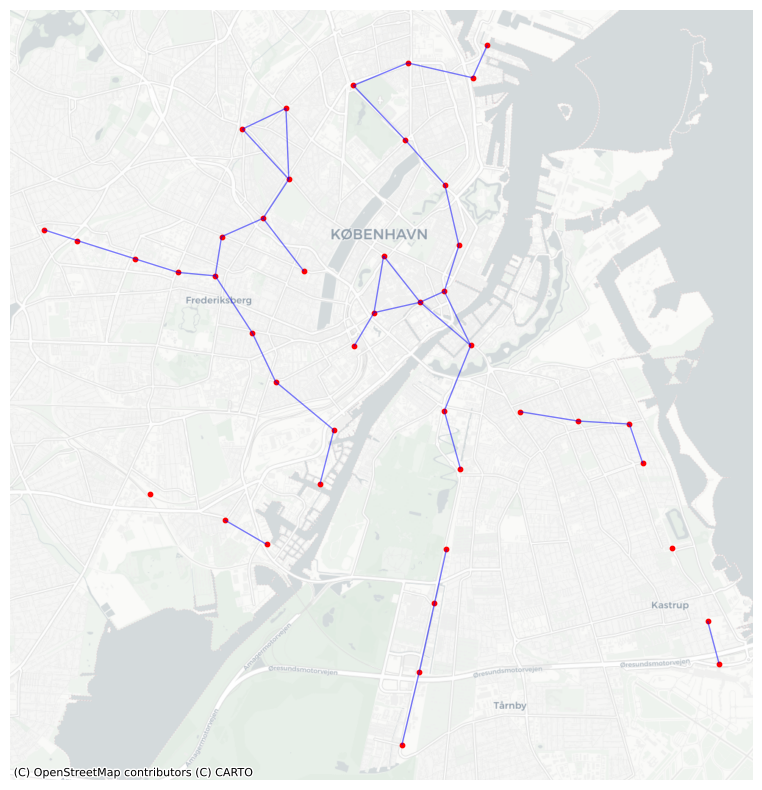

In [113]:
# 2) build LineString geometry for each edge
def make_line(row):
    p1 = stops.loc[row["u"], "geometry"]
    p2 = stops.loc[row["v"], "geometry"]
    return LineString([p1, p2])

edges_gdf = gpd.GeoDataFrame(
    edges.copy(),
    geometry=edges.apply(make_line, axis=1),
    crs=gdf_stops_3857.crs
)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

edges_gdf.plot(ax=ax, color="blue", alpha=0.5, linewidth=1)
gdf_stops_3857.plot(ax=ax, color="red", markersize=10)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, crs=gdf_stops_3857.crs)

ax.set_axis_off()
ax.set_aspect("equal")
plt.show()

In [110]:
def knn_edges_projected(gdf, id_col="stop_id", k=3, max_dist=None):
    """
    gdf: GeoDataFrame with Point geometry in a projected CRS (meters).
    max_dist: meters (optional). If set, drop neighbors farther than max_dist.
    Returns: DataFrame of edges (u, v, dist_m)
    """
    if gdf.crs is None:
        raise ValueError("gdf.crs is None. Set CRS before running kNN.")

    # If CRS is geographic (lat/lon), distances won't be meters → reproject
    gdf_utm = gdf.to_crs(gdf.estimate_utm_crs())

    gdf = gdf_utm[[id_col, "geometry"]].dropna().reset_index(drop=True)
    
    print(gdf.head())
    
    # coordinates in meters
    xs = gdf.geometry.x.to_numpy()
    ys = gdf.geometry.y.to_numpy()

    sindex = gdf.sindex
    edges = []

    for i, (u, x, y, geom) in enumerate(zip(gdf[id_col], xs, ys, gdf.geometry)):
        # Expand search window until we have enough candidates
        # (simple heuristic; works well for metro-scale datasets)
        r = 200.0  # start radius (m)
        cand_idx = []
        while len(cand_idx) < (k + 1):  # +1 includes itself
            bbox = (x - r, y - r, x + r, y + r)
            cand_idx = list(sindex.intersection(bbox))
            r *= 2
            if r > 50000:  # safety stop
                break

        # Compute distances to candidates
        dx = xs[cand_idx] - x
        dy = ys[cand_idx] - y
        d = np.hypot(dx, dy)

        # Sort by distance, skip itself
        order = np.argsort(d)
        picked = []
        for idx_in_list in order:
            j = cand_idx[idx_in_list]
            if j == i:
                continue
            dist_m = float(d[idx_in_list])
            if (max_dist is not None) and (dist_m > max_dist):
                continue
            picked.append((i, j, dist_m))
            if len(picked) >= k:
                break

        for _, j, dist_m in picked:
            v = gdf.loc[j, id_col]
            # undirected unique edge
            a, b = sorted((u, v))
            edges.append((a, b, dist_m))

    return pd.DataFrame(edges, columns=["u", "v", "dist_m"]).drop_duplicates()

edges_new = knn_edges_projected(gdf_stops_3857, id_col="stop_id", k=2, max_dist=1500)
print(edges_new.head())



   stop_id                        geometry
0  8603317  POINT (347310.264 6166387.238)
1  8603315  POINT (347605.405 6167453.405)
2  8603312    POINT (348066.915 6169235.6)
3  8603313  POINT (347863.034 6168446.486)
4  8603310  POINT (348105.355 6171264.121)
         u        v       dist_m
0  8603315  8603317  1106.264502
1  8603313  8603315  1025.954324
3  8603312  8603313   815.026663
4  8603311  8603312  1199.284699
7  8603310  8603311   879.704177


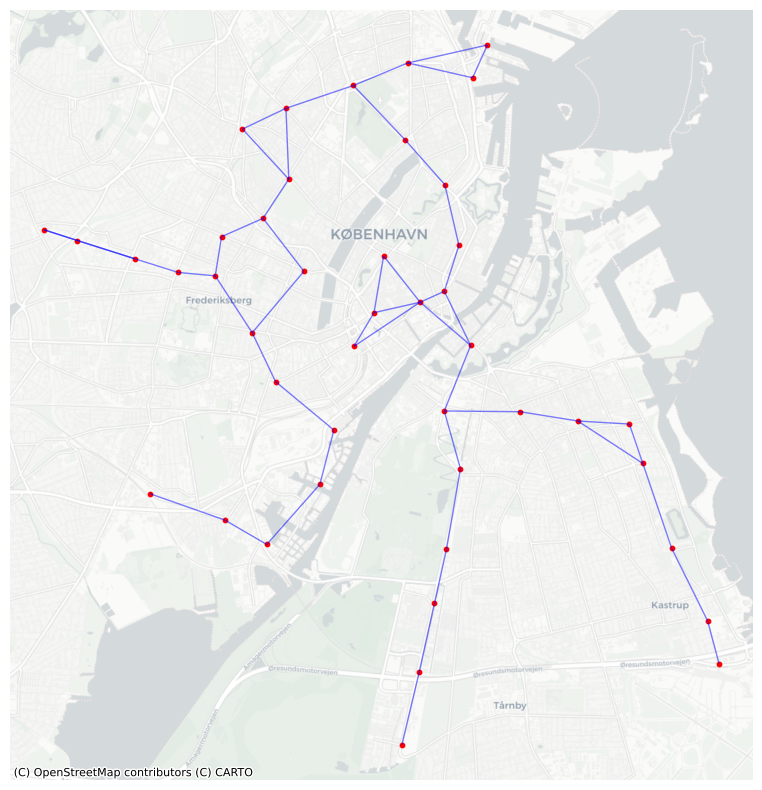

In [111]:
def make_line(row):
    p1 = stops.loc[row["u"], "geometry"]
    p2 = stops.loc[row["v"], "geometry"]
    return LineString([p1, p2])

edges_gdf_new = gpd.GeoDataFrame(
    edges_new.copy(),
    geometry=edges_new.apply(make_line, axis=1),
    crs=gdf_stops_3857.crs
)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

edges_gdf_new.plot(ax=ax, color="blue", alpha=0.5, linewidth=1)
gdf_stops_3857.plot(ax=ax, color="red", markersize=10)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, crs=gdf_stops_3857.crs)

ax.set_axis_off()
ax.set_aspect("equal")
plt.show()

Parameters:

- max_routes = 4 , the amount of metro lines
- max_stops = 17 (red line), so the metro line is not longer than actual one
- max_distance , distance between stops 
- 

In [ ]:
dict_nodes = {}

gdf_utm = gdf_stops_3857.to_crs(gdf_stops_3857.estimate_utm_crs())
gdf = gdf_utm[["stop_name", "geometry"]].dropna().reset_index(drop=True)
# print(gdf)

# x, y coordinates compatable to meters - two lists of coordinates
xs = gdf.geometry.x.to_numpy()
ys = gdf.geometry.y.to_numpy()

for i in gdf:
    


for i in G.nodes:
    dict_nodes[i] = []
# print(dict_nodes)
    
    

                             stop_name                        geometry
0               Vestamager St. (Metro)  POINT (347310.264 6166387.238)
1                  Ørestad St. (Metro)  POINT (347605.405 6167453.405)
2                   Sundby St. (Metro)    POINT (348066.915 6169235.6)
3             Bella Center St. (Metro)  POINT (347863.034 6168446.486)
4           Islands Brygge St. (Metro)  POINT (348105.355 6171264.121)
5                  DR Byen St. (Metro)  POINT (348313.202 6170409.323)
6           Kongens Nytorv St. (Metro)  POINT (348167.121 6173017.815)
7           Christianshavn St. (Metro)  POINT (348526.609 6172210.988)
8                    Forum St. (Metro)  POINT (346115.761 6173383.377)
9                Nørreport St. (Metro)  POINT (347293.627 6173567.187)
10                Fasanvej St. (Metro)   POINT (344271.591 6173431.94)
11           Frederiksberg St. (Metro)  POINT (344811.473 6173363.003)
12               Flintholm St. (Metro)  POINT (342806.566 6173952.286)
13    